# ANÁLISIS DE CONVERGENCIA

Se presenta un análisis de convergencia para el método ts-MULE (Schlegel et al. 2021), con el objetivo de determinar los hiperparámetros que permiten una buena explicación de la predicción del modelo. Para ello, se implementa ts-MULE con diversas explicaciones por prediccción, análizando tasas de cambio y graficando resultados.

<u>Referencias:</u>
- Schlegel, U., Lam, D. V., Keim, D. A., & Seebacher, D. (2021). TS-MULE: Local Interpretable Model-Agnostic Explanations for Time Series Forecast Models. Joint European Conference on Machine Learning and Knowledge Discovery in Databases, 5–14. http://arxiv.org/abs/2109.08438

In [1]:
import os, sys, warnings, pickle
import numpy as np
import pandas as pd

# Add module tsmule to syspath
print("Current working dir:", os.getcwd())
sys.path.insert(0, 'METHODS/ts-mule')

# Filter out all RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning) 

import logging 
logging.getLogger("stumpy").setLevel(logging.ERROR)

Current working dir: C:\Users\asuso\Documents\UTFSM\Doctorado Ing Aplicada\Cursos\INF473 - Introducción XAI\Proyecto\repo


In [2]:
#Cargar datos
with open('DATA\\xtest_new.pickle', 'rb') as file:
    # Load the data from the file
    X_test = pickle.load(file)


In [3]:
#Cargar modelo
import keras
from keras.models import load_model

model = load_model('MODELS\\transfer_learned_tsunami_classifier.keras')

C:\Users\asuso\anaconda3\envs\XAI2026_proj_v2\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [6]:
# Seleccionar muestra de los datos de test
m = 39
instancia = X_test[m:m+1]  # serie de tsunami a evaluar
#instancia = X_test[m]
#n_steps, features = X_nuevo.shape
model.predict(instancia)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step


array([[0.7744924]], dtype=float32)

Se estableció n_samples=100 por defecto, considerando:
1. Dimensión del problema: series de (241, 6) con ~5-40 segmentos activos — 100 muestras es más que suficiente para ajustar una regresión con esa cantidad de variables
2. Compensación con n_runs: estás promediando 300 iteraciones, lo que compensa la varianza de cada estimación individual — es preferible más iteraciones con menos muestras que pocas iteraciones con muchas muestras
3. Precedente en literatura: valores entre 50-200 son estándar en implementaciones LIME para series de tiempo

In [8]:
from xai_utils import run_tsmule_convergence

df_conv = run_tsmule_convergence(
    model=model,
    x=instancia,
    runs_to_test=[10, 25, 50, 100, 200, 300, 400, 500, 750, 1000],
    save_path='CONVERGENCIA_TSMULE\\'
)

Iniciando análisis de convergencia desde cero.

Iteraciones pendientes: 1000
Bloques pendientes: [10, 25, 50, 100, 200, 300, 400, 500, 750, 1000]
Inicio: 21:39:37

------------------------------------------------------------
n=  10 | diff=nan | rango=[-0.2059, 0.1900] | no_nulos=100.0% | t=2.6 min | fin: 21:42:13
n=  25 | diff=0.023402 | rango=[-0.1931, 0.1876] | no_nulos=100.0% | t=1.4 min | fin: 21:43:39
n=  50 | diff=0.015145 | rango=[-0.1702, 0.1805] | no_nulos=100.0% | t=2.5 min | fin: 21:46:11
n= 100 | diff=0.013534 | rango=[-0.1797, 0.1625] | no_nulos=100.0% | t=5.1 min | fin: 21:51:15
n= 200 | diff=0.010276 | rango=[-0.1827, 0.1731] | no_nulos=100.0% | t=9.8 min | fin: 22:01:05
n= 300 | diff=0.003617 | rango=[-0.1928, 0.1851] | no_nulos=100.0% | t=9.8 min | fin: 22:10:52
n= 400 | diff=0.004424 | rango=[-0.1923, 0.1812] | no_nulos=100.0% | t=9.9 min | fin: 22:20:44
n= 500 | diff=0.002169 | rango=[-0.1926, 0.1791] | no_nulos=100.0% | t=9.9 min | fin: 22:30:35
n= 750 | diff=0.0032

| n_runs | diff_media | rango_min | rango_max | % no nulos | tiempo (min) |
|:-:|:-:|:-:|:-:|:-:|:-:|
| 10   | --       | -0.2059 | 0.1900 | 100.0 | 2.6  |
| 25   | 0.023402 | -0.1931 | 0.1876 | 100.0 | 1.4  |
| 50   | 0.015145 | -0.1702 | 0.1805 | 100.0 | 2.5  |
| 100  | 0.013534 | -0.1797 | 0.1625 | 100.0 | 5.1  |
| 200  | 0.010276 | -0.1827 | 0.1731 | 100.0 | 9.8  |
| **300**  | **0.003617** | **-0.1928** | **0.1851** | **100.0** | **9.8**  |
| 400  | 0.004424 | -0.1923 | 0.1812 | 100.0 | 9.9  |
| 500  | 0.002169 | -0.1926 | 0.1791 | 100.0 | 9.9  |
| 750  | 0.003296 | -0.1844 | 0.1825 | 100.0 | 24.8 |
| 1000 | 0.001854 | -0.1810 | 0.1786 | 100.0 | 25.0 |

Conclusión preliminar
El punto de estabilización parece estar alrededor de n=300-500, donde la diff_media baja de 0.004 y se mantiene estable. El repunte en n=300→400 es probablemente ruido estocástico.

Con el objetivo de determinar el número óptimo de iteraciones para ts-MULE, se realizó un análisis de convergencia evaluando bloques acumulativos de n_runs ∈ {10, 25, 50, 100, 200, 300, 400, 500, 750, 1000}, midiendo la diferencia media absoluta entre promedios de relevancia de bloques consecutivos. Los resultados muestran que el 100% de los valores de relevancia son no nulos en todos los bloques, lo que indica que la configuración de parámetros es adecuada para esta instancia. La diferencia media disminuye progresivamente desde 0.0234 (n=25) hasta estabilizarse en torno a 0.002-0.004 a partir de n=300, donde se observa una caída significativa respecto al bloque anterior. Si bien se registra un ligero repunte en n=400 (0.0044), esto se atribuye a variabilidad estocástica inherente al método, ya que los bloques posteriores confirman la estabilización. Por esta razón, se seleccionó n=300 como configuración óptima, ofreciendo un equilibrio entre estabilidad de los resultados y eficiencia computacional, con un tiempo de ejecución de 9.8 minutos.

In [25]:
import matplotlib.pyplot as plt

def plot_tsmule_convergence(df, fig_fmt='png', save_path=None):
    """
    Gráfico de convergencia de relevancia promedio — ts-MULE.
    Muestra la diferencia media entre bloques y la estabilización del rango.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    n_runs    = df['n_runs'].values
    diff      = df['diff_media'].values
    rango_min = df['rango_min'].values
    rango_max = df['rango_max'].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Curva de convergencia
    axes[0].plot(n_runs[1:], diff[1:], marker='o', color='steelblue', linewidth=2)
    axes[0].axvline(x=300, color='red', linestyle='--', label='n=300 (recomendado)')
    axes[0].axhline(y=0.004, color='gray', linestyle=':', label='zona de estabilización')
    axes[0].set_xlabel('n_runs')
    axes[0].set_ylabel('Diferencia media')
    axes[0].set_title('Convergencia de relevancia promedio')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Estabilización del rango
    axes[1].plot(n_runs, rango_max, marker='o', color='orange',
                 linewidth=2, label='máx')
    axes[1].plot(n_runs, rango_min, marker='o', color='steelblue',
                 linewidth=2, label='mín')
    axes[1].axvline(x=300, color='red', linestyle='--', label='n=300 (recomendado)')
    axes[1].set_xlabel('n_runs')
    axes[1].set_ylabel('Relevancia')
    axes[1].set_title('Estabilización del rango de relevancia')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle('Análisis de convergencia — ts-MULE', fontsize=13)
    plt.tight_layout()

    if save_path:
        fig.savefig(f'{save_path}_convergencia_tsmule.{fig_fmt}',
                    format=fig_fmt, dpi=300, bbox_inches='tight')
        print(f"Figura guardada: {save_path}_convergencia_tsmule.{fig_fmt}")
    plt.show()


def plot_tsmule_convergence_time(df, fig_fmt='png', save_path=None):
    """
    Gráfico de tiempo de cómputo acumulado — ts-MULE.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    n_runs      = df['n_runs'].values
    tiempo_acum = np.cumsum(df['tiempo_min'].values)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(n_runs, tiempo_acum, marker='o', color='orange', linewidth=2,
            label='Tiempo acumulado')
    ax.axvline(x=300, color='red', linestyle='--', label='n=300 (recomendado)')

    ax.set_xticks(n_runs)
    ax.set_xticklabels(n_runs, rotation=45, ha='right')
    ax.set_xlabel('n_runs')
    ax.set_ylabel('Tiempo acumulado (min)')
    ax.set_title('Tiempo de cómputo acumulado — ts-MULE')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_yticks(np.arange(0, tiempo_acum.max() + 10, 10))

    
    plt.tight_layout()

    if save_path:
        fig.savefig(f'{save_path}_convergencia_tsmule_tiempo.{fig_fmt}',
                    format=fig_fmt, dpi=300, bbox_inches='tight')
        print(f"Figura guardada: {save_path}_convergencia_tsmule_tiempo.{fig_fmt}")
    plt.show()

In [ ]:
# Cargar resultados
with open('CONVERGENCIA_TSMULE\\tsmule_convergence_results.pkl', 'rb') as f:
    df_conv = pickle.load(f)

Figura guardada: CONVERGENCIA_TSMULE\_convergencia_tsmule.png


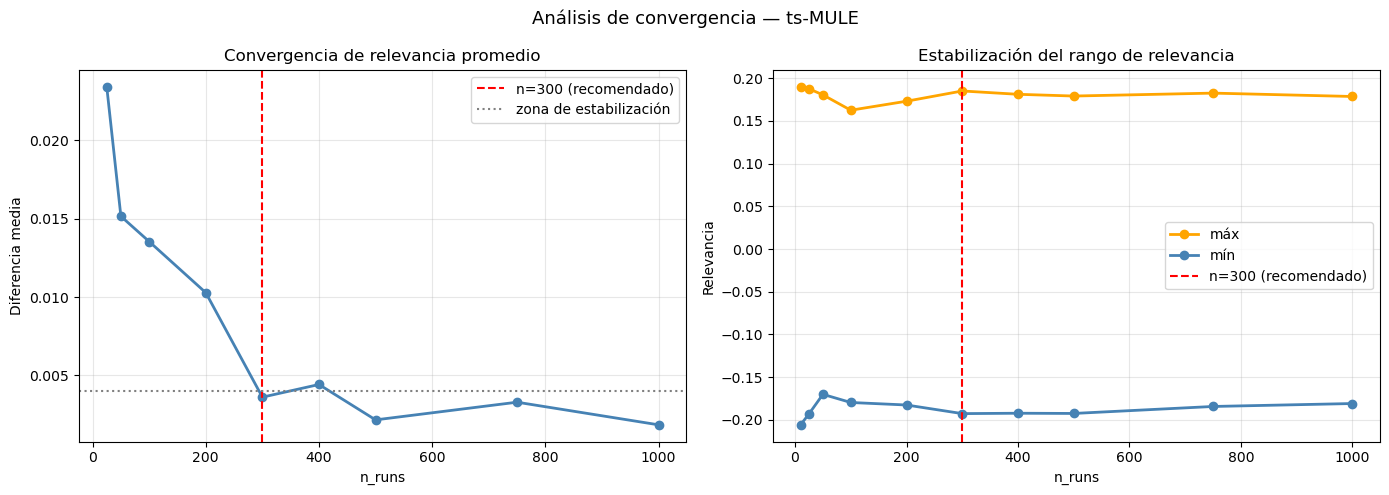

In [26]:
plot_tsmule_convergence(df_conv, fig_fmt='png',
                        save_path='CONVERGENCIA_TSMULE\\')

Figura guardada: CONVERGENCIA_TSMULE\_convergencia_tsmule_tiempo.png


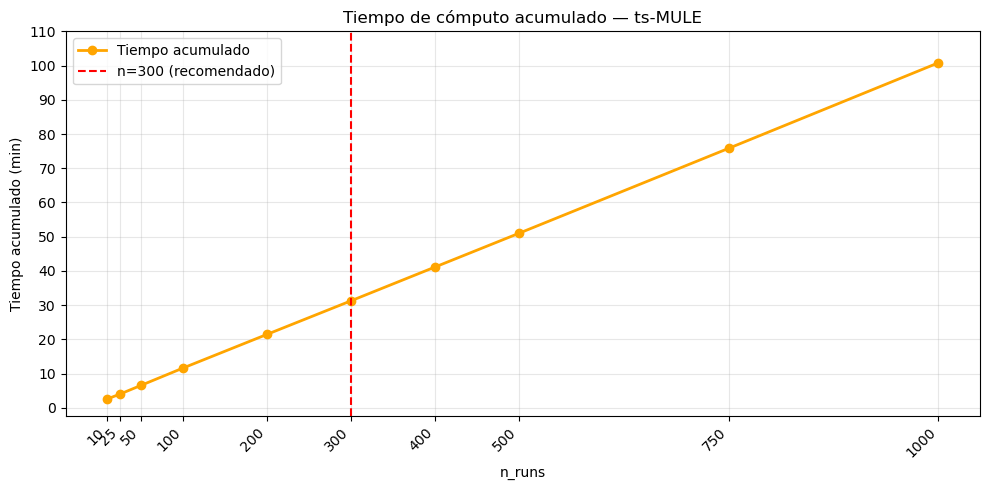

In [27]:
plot_tsmule_convergence_time(df_conv, fig_fmt='png',
                             save_path='CONVERGENCIA_TSMULE\\')